In [6]:
import pandas as pd

In [7]:
train_path = "../data-meta/GLC25_PA_metadata_train.csv"

In [8]:
train = pd.read_csv(train_path)

In [9]:
train[train["surveyId"] == 213527]

,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,speciesId,surveyId
79753,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,5739.0,213527
79754,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,6491.0,213527
79755,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,5526.0,213527
79756,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,3123.0,213527
79757,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,5980.0,213527
79758,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,5166.0,213527
79759,10.23389,56.51822,2019,10.0,79.0,CONTINENTAL,Denmark,2861.0,213527


In [10]:
train.columns

Index(['lon', 'lat', 'year', 'geoUncertaintyInM', 'areaInM2', 'region',
       'country', 'speciesId', 'surveyId'],
      dtype='object')

In [11]:
train[[ "surveyId","speciesId" ]].head(20)

,surveyId,speciesId
0,212,6874.0
1,212,476.0
2,212,11157.0
3,212,8784.0
4,212,4530.0
5,212,10520.0
6,212,9458.0
7,212,982.0
8,212,51.0
9,212,3935.0


In [37]:
test_path = "../data-meta/GLC25_PA_metadata_test.csv"

In [38]:
test = pd.read_csv(test_path)

In [12]:
cubes_path = "/data/challenge2026MIASHS/BioclimTimeSeries/cubes/PA-train"

Fichier trouvé !


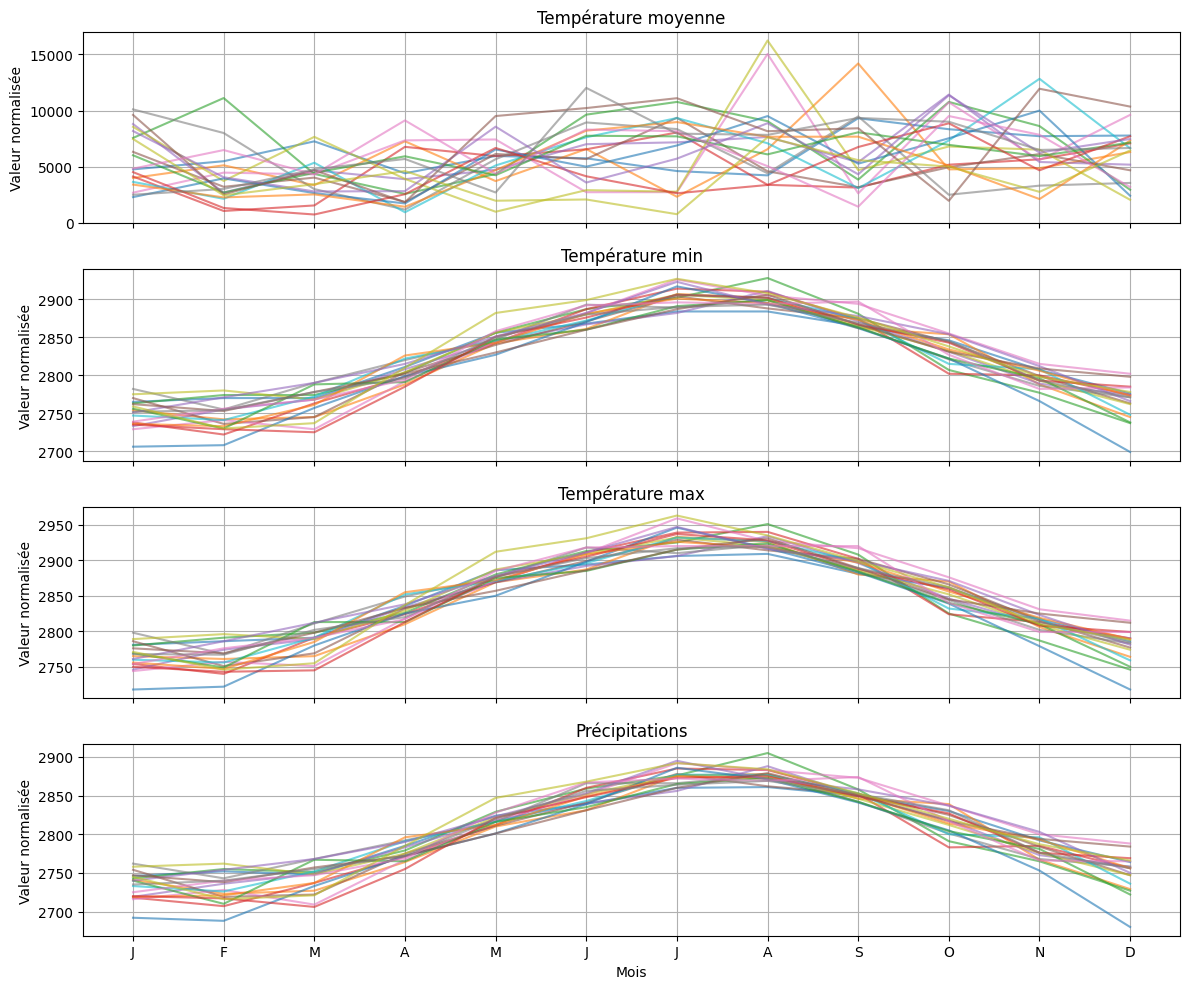

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

fichier = "GLC25-PA-train-bioclimatic_monthly_213527_cube.pt"
chemin_complet = os.path.join(cubes_path, fichier)

if os.path.exists(chemin_complet):
    print("Fichier trouvé !")
else:
    print("Fichier introuvable. Vérifie le chemin.")

cube = torch.load(chemin_complet)

# Noms des variables
variable_names = ["Température moyenne", "Température min", "Température max", "Précipitations"]

# Tracer chaque variable
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)
for i in range(4):
    ax = axes[i]
    data = cube[i, :, :]

    # Tracer chaque année comme une ligne
    for year in range(19):
        ax.plot(range(1, 13), data[year, :], label=f"Année {2000 + year}", alpha=0.6)

    ax.set_title(variable_names[i])
    ax.set_ylabel("Valeur normalisée")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.grid(True)

axes[-1].set_xlabel("Mois")
plt.tight_layout()
plt.show()

In [14]:
import os

taille = os.path.getsize(chemin_complet)
print(f"Taille du fichier : {taille} octets")

# Lire les 10 premiers octets pour vérifier si le fichier est vide ou corrompu
with open(chemin_complet, 'rb') as f:
    debut = f.read(10)
    print(f"Début du fichier (10 octets) : {debut}")

Taille du fichier : 5151 octets
Début du fichier (10 octets) : b'PK\x03\x04\x00\x00\x08\x08\x00\x00'


### Merge train + cubes

In [ ]:
df = pd.DataFrame()
df["surveyId"] = train["surveyId"]
df["speciesId"] = train["speciesId"]

df["cube_path"] = df["surveyId"].apply(
    lambda x: os.path.join(
        cubes_path,
        f"GLC25-PA-train-bioclimatic_monthly_{x}_cube.pt"
    )
)

In [16]:
df.head()

,surveyId,speciesId,cube_path
0,212,6874.0,/data/challenge2026MIASHS/BioclimTimeSeries/cu...
1,212,476.0,/data/challenge2026MIASHS/BioclimTimeSeries/cu...
2,212,11157.0,/data/challenge2026MIASHS/BioclimTimeSeries/cu...
3,212,8784.0,/data/challenge2026MIASHS/BioclimTimeSeries/cu...
4,212,4530.0,/data/challenge2026MIASHS/BioclimTimeSeries/cu...


### Utilisation de 8 coeurs

In [17]:
import os
import torch

# Limiter PyTorch à 8 threads (1 par cœur)
torch.set_num_threads(8)
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["VECLIB_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

In [18]:
print(f"PyTorch utilise {torch.get_num_threads()} threads.")

PyTorch utilise 8 threads.


In [19]:
from torch.utils.data import DataLoader, TensorDataset

#dataset = TensorDataset(cubes, labels)
dataloader = DataLoader(
    dataset,
    batch_size=32,  # À ajuster selon la mémoire
    shuffle=True,
    num_workers=4,  # 4 workers pour 8 cœurs
    pin_memory=False  # Utile seulement pour le GPU
)

NameError: name 'dataset' is not defined

### Modele res net6

In [31]:
import pickle

def load_cube(path):
    data = np.load(path, allow_pickle=True)

    # cas NPZ
    if isinstance(data, np.lib.npyio.NpzFile):
        for k in data.files:
            arr = data[k]

            # cas normal
            if isinstance(arr, np.ndarray):
                return arr

            # cas bytes / object
            if isinstance(arr, (bytes, np.void)):
                try:
                    return np.frombuffer(arr, dtype=np.float32)
                except:
                    return pickle.loads(arr)

        raise ValueError("No valid array found in npz")

    return data

In [32]:
def cube_to_image(cube):
    # Exemple simple : prendre 3 slices
    if cube.shape[0] >= 3:
        img = cube[:3]
    else:
        # padding si moins de 3
        img = np.repeat(cube[0:1], 3, axis=0)

    return img

In [33]:
import torch
import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)

# enlever la dernière couche (classification)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

/home/grp3/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/grp3/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [34]:
def extract_features(img):
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        features = resnet(img)
    
    return features.flatten().numpy()

In [35]:
df["features"] = df["cube_path"].apply(lambda p: extract_features(cube_to_image(load_cube(p))))

# grouper
X = df.groupby("surveyId")["features"].apply(lambda x: np.mean(list(x), axis=0))

UnpicklingError: A load persistent id instruction was encountered,
but no persistent_load function was specified.

In [28]:
path = df["cube_path"].iloc[0]

data = np.load(path, allow_pickle=True)

print(type(data))
print(data.files)

<class 'numpy.lib.npyio.NpzFile'>
['GLC24-PA-train-bioclimatic_monthly_212_cube/data.pkl', 'GLC24-PA-train-bioclimatic_monthly_212_cube/byteorder', 'GLC24-PA-train-bioclimatic_monthly_212_cube/data/0', 'GLC24-PA-train-bioclimatic_monthly_212_cube/version', 'GLC24-PA-train-bioclimatic_monthly_212_cube/.data/serialization_id']


In [29]:
for k in data.files:
    print(k, type(data[k]), getattr(data[k], "shape", None))

GLC24-PA-train-bioclimatic_monthly_212_cube/data.pkl <class 'bytes'> None
GLC24-PA-train-bioclimatic_monthly_212_cube/byteorder <class 'bytes'> None
GLC24-PA-train-bioclimatic_monthly_212_cube/data/0 <class 'bytes'> None
GLC24-PA-train-bioclimatic_monthly_212_cube/version <class 'bytes'> None
GLC24-PA-train-bioclimatic_monthly_212_cube/.data/serialization_id <class 'bytes'> None


### Noah Shit

In [36]:
from torch.utils.data import Dataset, DataLoader, random_split
from typing import Optional
import math
import glob


class LandsatCubeDataset(Dataset):
    def __init__(self, root_dir: str, labels: Optional[dict] = None, transform=None):
        """
        labels=None pour les données de test (inférence seule).
        """
        all_files = sorted(glob.glob(os.path.join(root_dir, "*.pt")))
        if labels is not None:
            self.files = [f for f in all_files if self._sid(f) in labels]
            if not self.files:
                raise ValueError("Aucun cube ne correspond aux surveyId du CSV.")
        else:
            self.files = all_files          # mode test : on prend tout

        self.labels    = labels
        self.transform = transform
        print(f"Cubes disponibles : {len(all_files):,}")
        print(f"Cubes utilisés    : {len(self.files):,}")

    @staticmethod
    def _sid(path: str) -> int:
        return int(os.path.basename(path).split("_")[-2])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        cube = torch.load(self.files[idx], map_location="cpu").float()
        cube = torch.nan_to_num(cube, nan=0.0, posinf=0.0, neginf=0.0)

        # Padding temporel à 21 si nécessaire
        if cube.shape[2] < 21:
            pad  = torch.zeros(6, 4, 21 - cube.shape[2])
            cube = torch.cat([cube, pad], dim=2)

        # Normalisation min-max par bande (préserve les contrastes spectraux)
        c_min = cube.flatten(1).min(dim=1).values[:, None, None]
        c_max = cube.flatten(1).max(dim=1).values[:, None, None]
        cube  = (cube - c_min) / (c_max - c_min + 1e-6)

        if self.transform:
            cube = self.transform(cube)

        if self.labels is not None:
            return cube, self.labels[self._sid(self.files[idx])]
        return cube,                        # tuple à 1 élément en mode test


# =============================================================================
# SPLIT TRAIN / VALIDATION
# =============================================================================

def make_dataloaders(dataset, val_ratio=0.15, batch_size=64, num_workers=4, seed=42):
    n_val   = math.floor(len(dataset) * val_ratio)
    n_train = len(dataset) - n_val

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    print(f"\nSplit  →  train : {n_train:,}  |  val : {n_val:,}  ({val_ratio:.0%})")
    return train_loader, val_loader, val_ds